In [99]:
"""A SpamGuard Classifier is a machine learning-based system designed to automatically identify whether
a message is spam or legitimate (ham). It works by analyzing textual features such as word frequency, 
patterns, and message structure using techniques like Naive Bayes and other machine learning algorithms. 
By learning from previously labeled data, the classifier can accurately predict and filter unwanted messages,
helping improve communication security, reduce spam, and enhance the overall user experience. In this project,
we will also compare the performance of different machine learning algorithms to determine which model provides
the best accuracy and reliability for spam detection."""


'A SpamGuard Classifier is a machine learning-based system designed to automatically identify whether\na message is spam or legitimate (ham). It works by analyzing textual features such as word frequency, \npatterns, and message structure using techniques like Naive Bayes and other machine learning algorithms. \nBy learning from previously labeled data, the classifier can accurately predict and filter unwanted messages,\nhelping improve communication security, reduce spam, and enhance the overall user experience. In this project,\nwe will also compare the performance of different machine learning algorithms to determine which model provides\nthe best accuracy and reliability for spam detection.'

In [100]:
import numpy as np
import pandas as pd

In [101]:
dataset = pd.read_csv('spam.csv', encoding='latin-1')

In [102]:
df = dataset.copy()

In [103]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [104]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2638,ham,Am in gobi arts college,NaN,NaN,NaN
2557,spam,This message is brought to you by GMW Ltd. and...,NaN,NaN,NaN
3147,ham,\CHEERS U TEX MECAUSE U WEREBORED! YEAH OKDEN ...,NaN,NaN,NaN
2107,ham,Hmmm ... And imagine after you've come home fr...,NaN,NaN,NaN
2253,ham,Lol enjoy role playing much?,NaN,NaN,NaN


In [105]:
df.shape

(5572, 5)

### Project Steps  
1. `Data` `Cleaning`  
2. `Exploratory` `Data` `Analysis` `(EDA)`  
3. `Text Preprocessing`  
4. `Model Building`  
5. `Evaluation`  
6. `Improvements`  
7. `Convert into Website`  
8. `Deployment`

### 1. Data Cleaning

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


As we see in unnamed: 2,3 and 4 have low count value, it meanse they have alot of missing value

In [107]:
# so for this we will drop last 3 cloumns
# for perminent operration we will use inplace=True

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [108]:
df.sample(5)

,v1,v2
3389,spam,Please CALL 08712402972 immediately as there i...
2689,ham,"Ya ok, vikky vl c witin &lt;#&gt; mins and il..."
3481,spam,Do you want a NEW video phone750 anytime any n...
5194,ham,Ok... Take ur time n enjoy ur dinner...
2994,ham,Mm not entirely sure i understood that text bu...


#### Rename the columns `v1` and `v2`

In [109]:
# use rename function

df.rename(columns = {'v1':'target', 'v2':'text'}, inplace = True)
df.sample(5)

,target,text
3221,ham,"Hi, my love! How goes that day? Fuck, this mor..."
2313,ham,So what do you guys do.
5021,ham,Yes its possible but dint try. Pls dont tell t...
2206,spam,"URGENT! Your mobile No 07xxxxxxxxx won a å£2,0..."
4906,ham,Then anything special?


#### As we see in target column    

there are two valuse ham or spam but  
we need numbers now we will convert it.  
   
we use **`LabelEncoder`**

In [110]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [111]:
encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0])

as we know 0 is for `ham` and 1 for `spam`  
now we will rewrite it like this

In [112]:
df['target'] = encoder.fit_transform(df['target'])

In [113]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [114]:
# now the data is cleaded
# 2 things always remember 1 is missing value, 2 duplicate values
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [115]:
# duplicate values

df.duplicated().sum()

403

In [116]:
# now remove duplicates

df.drop_duplicates(keep = 'first')

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [117]:
# we can also do the same 
df = df.drop_duplicates(keep = 'first')

In [118]:
df.duplicated().sum()

0

In [119]:
df.shape

(5169, 2)

### 2. Exploratory Data Analysis (`EDA`)

In [120]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [121]:
#we will check the ham (0) and spam (1) in target column
df['target'].value_counts()
#counts = df['target'].value_counts()
#counts

0    4516
1     653
Name: target, dtype: int64

In [122]:
#as we confirm the count of spam and ham 
# now will present in pie chart

import matplotlib.pyplot as plt

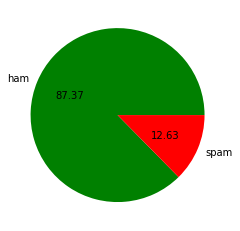

In [123]:
plt.pie(
    df['target'].value_counts(),
    labels= ['ham','spam'],
    autopct='%0.2f',
    colors=['green', 'red']
)

plt.show()

In [124]:
# Data is imbalanced
#now we will use nltk labriry to count 
#characters, words and sentence
#as i have already installed
#!pip install nltk

In [125]:
import nltk

In [126]:
# i have downloaded
#nltk.download('punkt')
# now for deep analysis we will make 3 more columns

In [127]:
df['text'].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [128]:
#now we add num_characters column after text

df['num_characters'] = df['text'].apply(len)

In [129]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [130]:
# now we will fetch num of words

df['text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [131]:
#we get each sms word by word in list
# and count its lenth is easy

df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [132]:
#add another column 'num_words'

df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [133]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [134]:
df.shape

(5169, 4)

In [135]:
# sent_tokenize words to break or make small parts of msg

df['text'].apply(lambda x:nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [136]:
# now we will add another column for sentence
# and also use len() to find number of sentence 

df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [137]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [138]:
#describe the last 3 columns

df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [139]:
# we will analyze ham and spam seperately
#this is for ham msges

df[df['target'] == 0]

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
6,0,Even my brother is not like to speak with me. ...,77,18,2
...,...,...,...,...,...
5565,0,Huh y lei...,12,4,1
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [140]:
#this is for ham msges

df[df['target'] == 0] [['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [141]:
# for spam msges will do the same just put 1 instead of 0
df[df['target'] == 1]

,target,text,num_characters,num_words,num_sentences
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4
8,1,WINNER!! As a valued network customer you have...,158,32,5
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3
...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,38,6
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1


In [142]:
# for spam msges

df[df['target'] == 1] [['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


In [143]:
# to check the comperison through hitogram 
# import seaborn

import seaborn as sns

In [144]:
#first extract all the ham msges

df[df['target'] == 0]

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
6,0,Even my brother is not like to speak with me. ...,77,18,2
...,...,...,...,...,...
5565,0,Huh y lei...,12,4,1
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [145]:
# now take the num_characters column

df[df['target'] == 0]['num_characters']

0       111
1        29
3        49
4        61
6        77
       ... 
5565     12
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 4516, dtype: int64

In [146]:
#than extract all the spam msges

df[df['target'] == 1]

,target,text,num_characters,num_words,num_sentences
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4
8,1,WINNER!! As a valued network customer you have...,158,32,5
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3
...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,38,6
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1


In [147]:
# now take the num_characters column

df[df['target'] == 1]['num_characters']

2       155
5       148
8       158
9       154
11      136
       ... 
5537     90
5540    160
5547    160
5566    147
5567    161
Name: num_characters, Length: 653, dtype: int64

<AxesSubplot:xlabel='num_characters', ylabel='Count'>

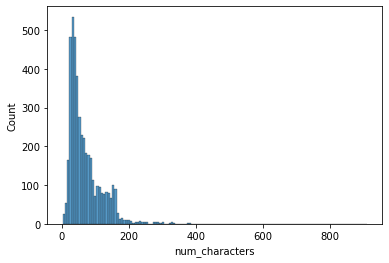

In [148]:
#histogram from ham messsages
sns.histplot(df[df['target'] == 0]['num_characters'])

<AxesSubplot:xlabel='num_characters', ylabel='Count'>

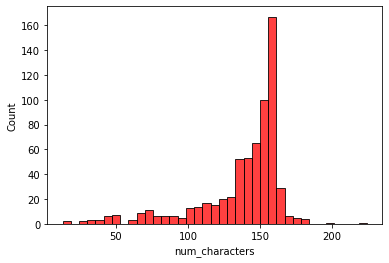

In [149]:
#histogram from spam messsages
sns.histplot(df[df['target'] == 1]['num_characters'], color ='red')

<AxesSubplot:xlabel='num_characters', ylabel='Count'>

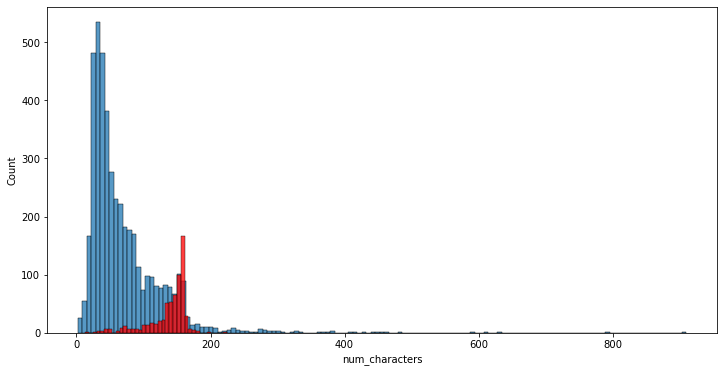

In [150]:
# plot the histo for both ham and spam
# on characters
plt.figure(figsize = (12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color ='red')

<AxesSubplot:xlabel='num_words', ylabel='Count'>

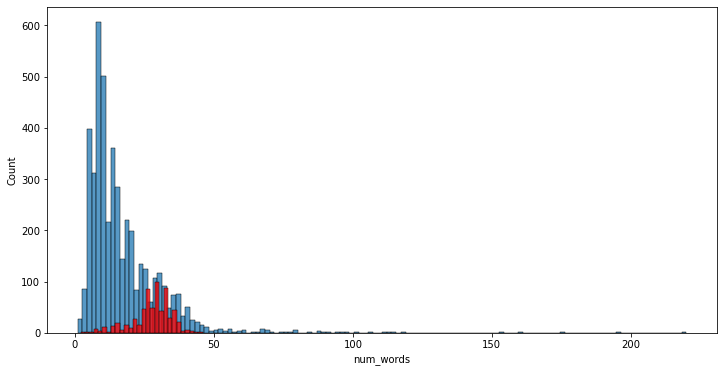

In [151]:
# plot for words

plt.figure(figsize = (12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color ='red')

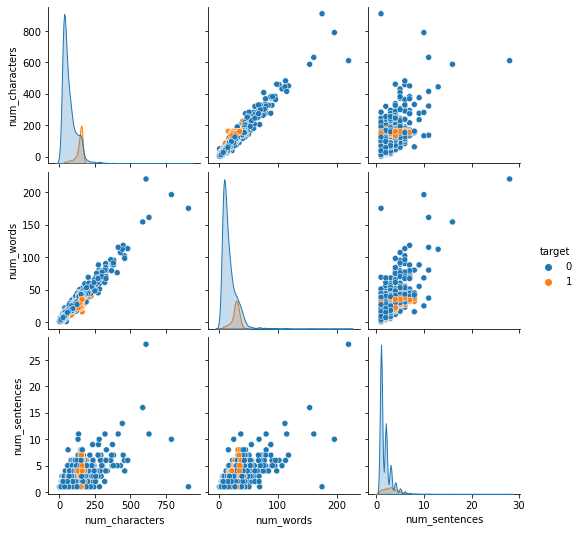

In [152]:
#check the relation between eacht other (num_characters,
#                        num_words,num_sentences)

sns.pairplot(df,hue= 'target')

In [153]:
#to cfind corelation coofiecien
df.corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262984,0.284901
num_characters,0.384717,1.000000,0.965770,0.638143
num_words,0.262984,0.965770,1.000000,0.684541
num_sentences,0.284901,0.638143,0.684541,1.000000


<AxesSubplot:>

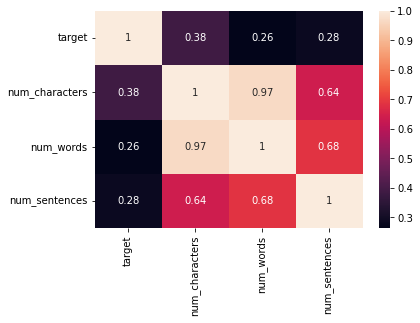

In [154]:
sns.heatmap(df.corr(),annot = True)

### 3. Data Preprocessing  

. `Low` `cases`  
. `Tokenization`  
.  Removing `special` `characters`  
.  Removing `stop` `words` and `punctuation`  
.  `Steming` means `same` meaning words like (`eat`,`ate`,`ate`)

In [155]:
from nltk.corpus import stopwords
#as already downloaded
#nltk.download('stopwords')

In [156]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [157]:
#for steming
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()

In [158]:
ps.stem('playing')

'play'

In [159]:
import string 
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [160]:
# make a function which will work for all as mentioned above in heading 3

def transform_text(text):
    
    text = text.lower() # to sole the lower case
    
    text = nltk.word_tokenize(text) # to solve tokenization
    
    y = []
    for i in text:         #we noly keep the alphabate and alphanumerics
        if i.isalnum():    #special characters will be removed
            y.append(i)
            
            
    text = y [:]
    y.clear()
                          #removing stop words and punctuation
                         
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
                         #clear the same meaning words only 
                         #return base form of word
    for i in text:
        y.append(ps.stem(i))
        
                           #joining strings
    return " ".join(y)

In [161]:
transform_text('''FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv''')

'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv'

In [162]:
df['text'][16]

"Oh k...i'm watching here:)"

In [163]:
#now we will create one more column, for first apply transform_text
#we get an output than will add in new clumn
df['text'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text, Length: 5169, dtype: object

In [164]:
#add column
df['transformed_text'] = df['text'].apply(transform_text)

In [165]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [166]:
#now we will work on transfored_text and keep the real text as it is 
#if we mistakes than we don't need for backtracking
#now our work will be with target and transformed_text

#### make `worldcloud`  

. this module is already in our envirnoment  
. so just import it  
. if you don't have like me than `install` it

In [167]:
#pip install wordcloud

In [168]:
import wordcloud
print(wordcloud.__version__)

1.9.6


In [169]:
#wordcloud → module (container)
#WordCloud → actual class we need to use
wc =wordcloud.WordCloud(
    width=500,
    height=400,
    min_font_size=10,
    background_color='white'      
       )

In [170]:
import PIL
print(PIL.__version__)

11.3.0


In [171]:
#spam_wc = wc.generate(text)

#plt.figure(figsize=(10,4))
#plt.imshow(spam_wc)
#plt.axis("off")  # Hides the x and y axis (numbers)
#plt.show()

In [172]:
#use generate fun for spam filtering in transformed_text

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

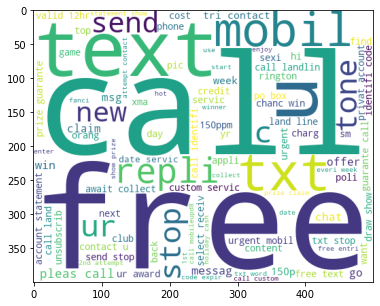

In [173]:
plt.figure(figsize=(10,5))  # to increase the fig size
plt.imshow(spam_wc)

In [174]:
#for ham messages do the same just change the spam_wc and from 1 to 0

ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

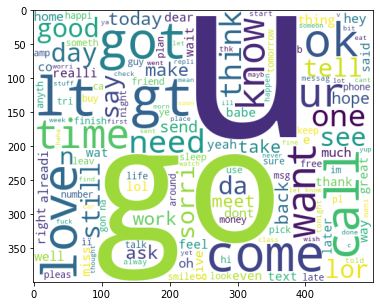

In [175]:
plt.figure(figsize=(10,5))  # to increase the fig size
plt.imshow(ham_wc)

In [176]:
# now we check for top 40 or 60 words in both ham and spam
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [177]:
#for spam masseges we will do work in steps in separate cell
# for batter understanding 
# this is the code 👇 
#here we separate all spam words
#spam_corpus = []      #empty list
#for msg in df[df['target'] == 1]['transformed_text'].tolist():
#    for word in msg.split():
#       spam_corpus.append(word)

In [178]:
#extract spam from transformed_text colunm also convert into list[]
df[df['target'] == 1]['transformed_text'].tolist()

['free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info',
 'urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 '07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow',
 '

In [179]:
#now apply loop on it, will print all spam msg
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    print(msg)

free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv
winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour
mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030
six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info
urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18
xxxmobilemovieclub use credit click wap link next txt messag click http
england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq
thank subscript rington uk mobil charg pleas confirm repli ye repli charg
07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow
sm ac sptv new jersey devil detroit red wi

In [180]:
#here we separate all spam words
spam_corpus = []      #empty list
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [181]:
#print the list
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [182]:
#to check the length of list
len(spam_corpus)

9939

In [183]:
#now import library for word repitations
from collections import Counter

In [184]:
Counter(spam_corpus)

Counter({'free': 191,
         'entri': 21,
         '2': 155,
         'wkli': 9,
         'comp': 8,
         'win': 48,
         'fa': 2,
         'cup': 3,
         'final': 14,
         'tkt': 2,
         '21st': 1,
         'may': 6,
         'text': 122,
         '87121': 2,
         'receiv': 31,
         'question': 9,
         'std': 6,
         'txt': 141,
         'rate': 26,
         'c': 45,
         'appli': 24,
         '08452810075over18': 1,
         'freemsg': 14,
         'hey': 5,
         'darl': 2,
         '3': 20,
         'week': 49,
         'word': 21,
         'back': 20,
         'like': 12,
         'fun': 8,
         'still': 5,
         'tb': 1,
         'ok': 5,
         'xxx': 10,
         'chg': 2,
         'send': 60,
         'rcv': 2,
         'winner': 13,
         'valu': 8,
         'network': 26,
         'custom': 42,
         'select': 26,
         'receivea': 1,
         'prize': 82,
         'reward': 9,
         'claim': 98,
         'cal

In [185]:
# now time for getting words what erver you want
Counter(spam_corpus).most_common(40)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45),
 ('custom', 42),
 ('messag', 42),
 ('guarante', 42),
 ('per', 41),
 ('chat', 38),
 ('tri', 37),
 ('msg', 35),
 ('draw', 35),
 ('number', 35),
 ('cs', 35)]

In [186]:
#add it in dataframe
pd.DataFrame(Counter(spam_corpus).most_common(40),columns=['words','count'])

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


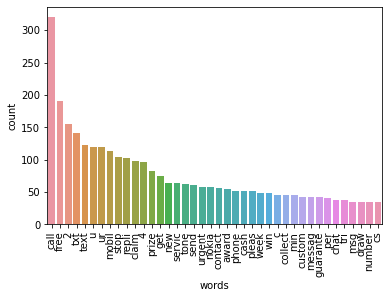

In [187]:
#plot these words
#sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(40))[0],pd.DataFrame(Counter(spam_corpus).most_common(40))[1])
#sns.barplot(x=df['words'], y=df['count'])
sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(40), columns=['words','count'])['words'],
    y=pd.DataFrame(Counter(spam_corpus).most_common(40), columns=['words','count'])['count']
)
plt.xticks(rotation=90)  #for batter reading
plt.show()

In [188]:
#now will separate ham masseges 
#but we use a single cell for code

ham_corpus = []      #empty list
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [189]:
len(ham_corpus)

35394

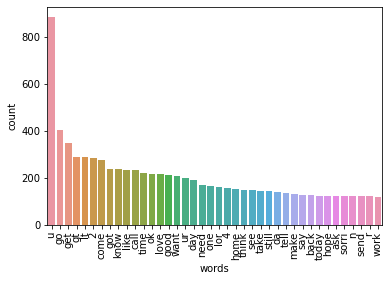

In [190]:
#here for ham we do all the steps in single cell 

#sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(40))[0],pd.DataFrame(Counter(ham_corpus).most_common(40))[1])
dfh = pd.DataFrame(
    Counter(ham_corpus).most_common(40),
    columns=['words', 'count']
)

sns.barplot(x=dfh['words'], y=dfh['count'])
plt.xticks(rotation=90)  #for batter reading
plt.show()

In [191]:
#text vectorization means convert text into number or vectors
#1st way using Bag of words
#2nd way tfidf
#3rd way word to vec
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [192]:
#first vectorize text using bag of words
#than will add as input to NievesBay

### 4. Model Building

In [193]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

##### we will check both  

but first will use `CounterVectorizer`  
than `TfidfVectorizer`

In [194]:
x = cv.fit_transform(df['transformed_text']).toarray()

In [195]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [196]:
x.shape

(5169, 6708)

In [197]:
y = df['target'].values

In [198]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [199]:
from sklearn.model_selection import train_test_split

In [200]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [201]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [202]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [203]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)

In [204]:
print('Accuracy: ',accuracy_score(y_test,y_pred1))
print('Confusion: ',confusion_matrix(y_test,y_pred1))
print('Precision_score: ',precision_score(y_test,y_pred1))

Accuracy:  0.8800773694390716
Confusion:  [[792 104]
 [ 20 118]]
Precision_score:  0.5315315315315315


In [205]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred2))
print('Confusion: ',confusion_matrix(y_test,y_pred2))
print('Precision_score: ',precision_score(y_test,y_pred2))

Accuracy:  0.9642166344294004
Confusion:  [[871  25]
 [ 12 126]]
Precision_score:  0.8344370860927153


In [206]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred3))
print('Confusion: ',confusion_matrix(y_test,y_pred3))
print('Precision_score: ',precision_score(y_test,y_pred3))

Accuracy:  0.9700193423597679
Confusion:  [[893   3]
 [ 28 110]]
Precision_score:  0.9734513274336283


##### now we will do the same for `tfidf`

In [207]:
xtf = tfidf.fit_transform(df['transformed_text']).toarray()

In [208]:
xtf.shape

(5169, 6708)

In [209]:
ytf = df['target'].values

In [210]:
ytf

array([0, 0, 1, ..., 0, 0, 0])

In [211]:
x_train,x_test,y_train,y_test = train_test_split(xtf,ytf,test_size=0.2,random_state=2)

In [212]:
#as we have already make objects just re use it
#gnb = GaussianNB()
#mnb = MultinomialNB()
#bnb = BernoulliNB()

In [213]:
#now we use GaussianNB on tfidf
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print('Accuracy: ',accuracy_score(y_test,y_pred1))
print('Confusion: ',confusion_matrix(y_test,y_pred1))
print('Precision_score: ',precision_score(y_test,y_pred1))

Accuracy:  0.8762088974854932
Confusion:  [[793 103]
 [ 25 113]]
Precision_score:  0.5231481481481481


In [214]:
#use mnb
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred2))
print('Confusion: ',confusion_matrix(y_test,y_pred2))
print('Precision_score: ',precision_score(y_test,y_pred2))

Accuracy:  0.9593810444874274
Confusion:  [[896   0]
 [ 42  96]]
Precision_score:  1.0


In [215]:
# bnb
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred3))
print('Confusion: ',confusion_matrix(y_test,y_pred3))
print('Precision_score: ',precision_score(y_test,y_pred3))

Accuracy:  0.9700193423597679
Confusion:  [[893   3]
 [ 28 110]]
Precision_score:  0.9734513274336283


In [216]:
#as we know precision_score is more important than 
#accuracy so we have both choices BernoulliNB and MultinomialNB with TfidfVectorizer
#but we will keep the MultinomialNB with TfidfVectorizer accuracy is 1.0
#because data is imbalanced accuracy doesn't matter precision_score does

##### Now we will use some other `ML` algorithms 

In [217]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [218]:
#now will make objects for each

lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
svc = SVC(kernel = 'sigmoid', gamma = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [219]:
#here we make a dictionary for all algorithms 
#so we trained all one by one 

clfs = {
    'LR' : lrc,
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'RF' : rfc,
    'AdaBoost': abc,
    'BgC' : bc,
    'ETC' : etc,
    'GBDT' : gbdt,
    'Xgb' : xgb
}

In [220]:
#now define a function for the above dic

def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred4 = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred4)
    precision = precision_score(y_test,y_pred4)
    
    return accuracy, precision
    

In [221]:
train_classifier(mnb,x_train,y_train,x_test,y_test)

(0.9593810444874274, 1.0)

In [222]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf,x_train,y_train,x_test,y_test)
    
    print('For ',name)
    print('Accuracy = ', current_accuracy)
    print('Precisioin =',current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
Accuracy =  0.9516441005802708
Precisioin = 0.94
For  SVC
Accuracy =  0.9729206963249516
Precisioin = 0.9741379310344828
For  KN
Accuracy =  0.9003868471953579
Precisioin = 1.0
For  NB
Accuracy =  0.9593810444874274
Precisioin = 1.0
For  DT
Accuracy =  0.9381044487427466
Precisioin = 0.8627450980392157
For  RF
Accuracy =  0.9738878143133463
Precisioin = 1.0
For  AdaBoost
Accuracy =  0.9613152804642167
Precisioin = 0.9454545454545454
For  BgC
Accuracy =  0.9584139264990329
Precisioin = 0.8625954198473282
For  ETC
Accuracy =  0.9758220502901354
Precisioin = 0.9829059829059829
For  GBDT
Accuracy =  0.9526112185686654
Precisioin = 0.9238095238095239
For  Xgb
Accuracy =  0.9729206963249516
Precisioin = 0.9365079365079365


In [223]:
#convert all in dataframe  
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores})

In [224]:
performance_df

,Algorithm,Accuracy,Precision
0,LR,0.951644,0.940000
1,SVC,0.972921,0.974138
2,KN,0.900387,1.000000
3,NB,0.959381,1.000000
4,DT,0.938104,0.862745
5,RF,0.973888,1.000000
6,AdaBoost,0.961315,0.945455
7,BgC,0.958414,0.862595
8,ETC,0.975822,0.982906
9,GBDT,0.952611,0.923810


In [225]:
#table based on high accuracy
performance_df_ac = pd.DataFrame({'Algorithm':clfs.keys(),
                                  'Accuracy':accuracy_scores,
                                  'Precision':precision_scores}).sort_values('Accuracy',ascending=False)
performance_df_ac

,Algorithm,Accuracy,Precision
8,ETC,0.975822,0.982906
5,RF,0.973888,1.000000
1,SVC,0.972921,0.974138
10,Xgb,0.972921,0.936508
6,AdaBoost,0.961315,0.945455
3,NB,0.959381,1.000000
7,BgC,0.958414,0.862595
9,GBDT,0.952611,0.923810
0,LR,0.951644,0.940000
4,DT,0.938104,0.862745


In [226]:
#based on precision
performance_df_pre = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df_pre

,Algorithm,Accuracy,Precision
2,KN,0.900387,1.000000
3,NB,0.959381,1.000000
5,RF,0.973888,1.000000
8,ETC,0.975822,0.982906
1,SVC,0.972921,0.974138
6,AdaBoost,0.961315,0.945455
0,LR,0.951644,0.940000
10,Xgb,0.972921,0.936508
9,GBDT,0.952611,0.923810
4,DT,0.938104,0.862745


In [227]:
df_melted = performance_df_pre.melt(
    id_vars='Algorithm',
    var_name='variable',
    value_name='values'
)

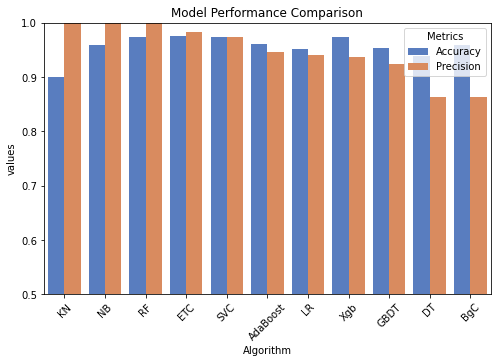

In [228]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Algorithm',
    y='values',
    hue='variable',
    palette='muted',
    data=df_melted
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.legend(title='Metrics')
plt.show()

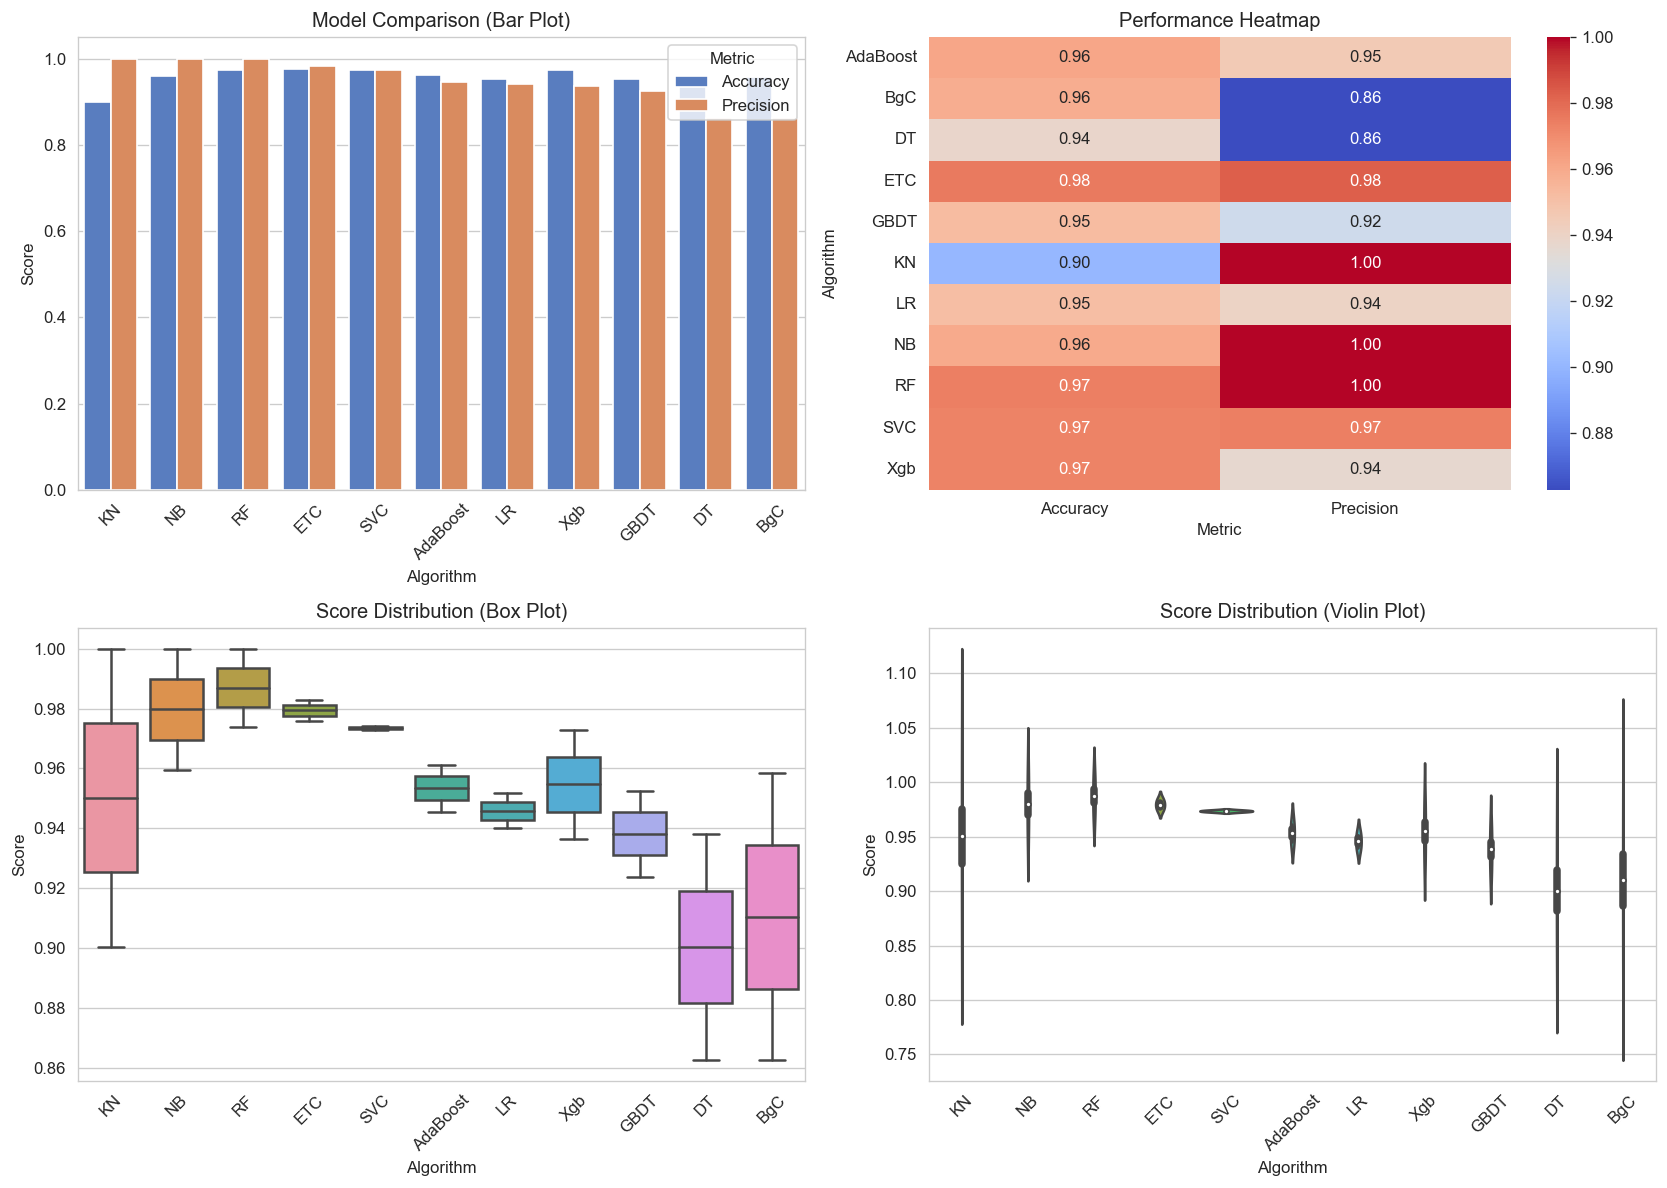

In [229]:
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 120


#Convert to long format
df_melted = performance_df_pre.melt(
    id_vars='Algorithm',
    var_name='Metric',
    value_name='Score'
)

#Create Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14,10))

#(1) Bar Plot
sns.barplot(
    x='Algorithm', y='Score', hue='Metric', palette='muted',
    data=df_melted, ax=axes[0,0]
)
axes[0,0].set_title("Model Comparison (Bar Plot)")
axes[0,0].tick_params(axis='x', rotation=45)

#(2) Heatmap
pivot_df = df_melted.pivot(index='Algorithm', columns='Metric', values='Score')
sns.heatmap(
    pivot_df, annot=True, fmt=".2f", cmap="coolwarm",
    ax=axes[0,1]
)
axes[0,1].set_title("Performance Heatmap")

#(3) Box Plot
sns.boxplot(
    x='Algorithm', y='Score',
    data=df_melted, ax=axes[1,0]
)
axes[1,0].set_title("Score Distribution (Box Plot)")
axes[1,0].tick_params(axis='x', rotation=45)

#(4) Violin Plot
sns.violinplot(
    x='Algorithm', y='Score',
    data=df_melted, ax=axes[1,1]
)
axes[1,1].set_title("Score Distribution (Violin Plot)")
axes[1,1].tick_params(axis='x', rotation=45)

#Final Layout
plt.tight_layout()
plt.show()

In [230]:
#now will improve model
#1. change the max_features parameters of TfIdf
#as we import TfIdf vectorizer class in above work, there is hidden 
#parameter max_feature here we didn't give any number of words we will provide 
#max_feature 3000

In [231]:
#for best result we will use max_features
tfidf_mf = TfidfVectorizer(max_features=3000)

In [232]:
xtf_mf = tfidf_mf.fit_transform(df['transformed_text']).toarray()

In [233]:
xtf_mf.shape

(5169, 3000)

In [234]:
ytf_mf = df['target'].values

In [235]:
ytf_mf

array([0, 0, 1, ..., 0, 0, 0])

In [236]:
x_train,x_test,y_train,y_test = train_test_split(xtf_mf,ytf_mf,test_size=0.2,random_state=2)

In [237]:
#now we use GaussianNB on tfidf
gnb.fit(x_train,y_train)
y_pred1_mf = gnb.predict(x_test)
print('Accuracy: ',accuracy_score(y_test,y_pred1_mf))
print('Confusion: ',confusion_matrix(y_test,y_pred1_mf))
print('Precision_score: ',precision_score(y_test,y_pred1_mf))

Accuracy:  0.8694390715667312
Confusion:  [[788 108]
 [ 27 111]]
Precision_score:  0.5068493150684932


In [238]:
mnb.fit(x_train,y_train)
y_pred2_mf = mnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred2_mf))
print('Confusion: ',confusion_matrix(y_test,y_pred2_mf))
print('Precision_score: ',precision_score(y_test,y_pred2_mf))

Accuracy:  0.9709864603481625
Confusion:  [[896   0]
 [ 30 108]]
Precision_score:  1.0


In [239]:
# bnb
bnb.fit(x_train,y_train)
y_pred3_mf = bnb.predict(x_test)

print('Accuracy: ',accuracy_score(y_test,y_pred3_mf))
print('Confusion: ',confusion_matrix(y_test,y_pred3_mf))
print('Precision_score: ',precision_score(y_test,y_pred3_mf))

Accuracy:  0.9835589941972921
Confusion:  [[895   1]
 [ 16 122]]
Precision_score:  0.991869918699187


In [240]:
#as i have already save the model if you not please remove coments
"""import pickle
pickle.dump(tfidf_mf,open('vectorizer_spam.pkl','wb'))
pickle.dump(mnb,open('model_spam.pkl','wb'))"""

"import pickle\npickle.dump(tfidf_mf,open('vectorizer_spam.pkl','wb'))\npickle.dump(mnb,open('model_spam.pkl','wb'))"